## 0.0 References

I learnt about band structures and calculting elastic moduli (in passive structures) from these two reviews:

1. Lubensky, T. C., C. L. Kane, Xiaoming Mao, A. Souslov, and Kai Sun. “Phonons and Elasticity in Critically Coordinated Lattices.” Reports on Progress in Physics 78, no. 7 (2015).

2. Mao, X., and T. C. Lubensky. “Maxwell Lattices and Topological Mechanics.” The Annual Review of Condensed Matter Physics Is Annu. Rev. Condens. Matter Phys 9 (2018): 125–46.

And some theoretical work on "odd elasticity":

3. C. Scheibner et al., “Odd elasticity,” *Nature Physics* **16**, 475–480
   (2020).

The things I talked about, from my own work, are in these papers:

4. J. Binysh, G. Baardink, J. Veenstra, C. Coulais & A. Souslov, “More is
   Less in Unpercolated Active Solids,” *PRX* **16**, 021012 (2026).

5. J. Veenstra, C. Scheibner, M. Brandenbourger, J. Binysh, A. Souslov,
   V. Vitelli & C. Coulais, “Adaptive Locomotion of Active Solids,” *Nature*
   **639**, 935–941 (2025).
6. J. Binysh, J. Veenstra, V. Seinen, R. Naber, D. Robledo-Poisson, A. Hunt,
   W. van Saarloos, A. Souslov & C. Coulais, “Wave Coarsening Drives Time
   Crystallization in Active Solids,” arXiv:2508.20052.

7. Al-Izzi, Sami C., Yao Du, Jonas Veenstra, et al. “Nonreciprocal Buckling Makes Active Filaments Polyfunctional.” Proceedings of the National Academy of Sciences 123, no. 11 (2026): e2531723123. 


# 0.1 Visualizing active mechanical lattices and calculating elastic moduli

This notebook is a worked example of code that visualizes two-dimensional mechanical ball–spring lattices and
computes their vibrational spectra and elastic moduli. We are particularly
interested in active mechanical metamaterials, where bonds break reciprocal
symmetries [1]. Their vibrational spectra are non-Hermitian and classically
forbidden, “odd” elastic moduli can appear [2]. The implementation therefore
handles lattices whether or not they conserve energy.

This notebook is a Python conversion of `MoreIsLess_StaffPicks.nb`, an article I wrote for Wolfram found here: https://community.wolfram.com/groups/-/m/t/3716833?sortMsg=Likes 
In this python conversion, we use SymPy for analytical computations and Matplotlib graphics modules in this folder.

# 0.2 Goals For This Session

**Use any coding agent you would like, but try to do the hard parts yourself to get the feel! For the lattice definitions, this is best done with pen and paper** 

1. Get familiar the with basics of defining a mechanical lattice - this is mainly book-keeping. Codex is pretty good at autocompleting this book-keeping, but its worth doing it yourself once or twice to get the feel for it.

2. Get familiar with the idea of the dynamical matrices, and elastic moduli, of a mechanical lattice. Rather than delving deep into the mathematics, here we will use a package that carries out compuations for us, and we can focus on the concepts.



# 0.3 Importing modules

There are two python modules:
- "active_lattice_graphics.py" , which visualizes a mechanical lattice you specify 
- "linear_odd_elastodynamics.py", which performs computations to get the vibrational spectrum and elastic moduli of the lattice

We will use sympy, a python module that can do symbolic manipulation

In [2]:
from itertools import product
from pathlib import Path
import sys

# Work whether Jupyter starts in this folder or its parent folder.
for candidate in (Path.cwd(), Path.cwd() / "outputs"):
    if (candidate / "linear_odd_elastodynamics.py").exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "Could not find linear_odd_elastodynamics.py next to this notebook."
    )

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

try:
    from IPython.display import display
except ImportError:  # Makes the cells executable as a plain Python script too.
    display = print

import active_lattice_graphics as graphics
import linear_odd_elastodynamics as odd

sp.init_printing()
k, k_a, kappa, kappa_a = sp.symbols(
    "k k_a kappa kappa_a", real=True
)
qx, qy = sp.symbols("q_x q_y", real=True)
sqrt3 = sp.sqrt(3)

# 1: Defining and visualizing a lattice

A mechanical lattice is a collection of balls connected by bonds. The most
common bonds are longitudinal and torsional bonds, but these lattices also
include nonreciprocal variants. Reference [1] describes the bond mathematics
in detail; here we focus on the implementation and begin with a honeycomb
lattice.

A general lattice is defined by Bravais lattice vectors and the positions and
masses within its unit cell. Node references look at so:
`[node_number, [cell_1, cell_2]]`, including **1-based node numbers**.

## 1.1 Worked Example: a Honeycomb Lattice

# A Lattice Schematic

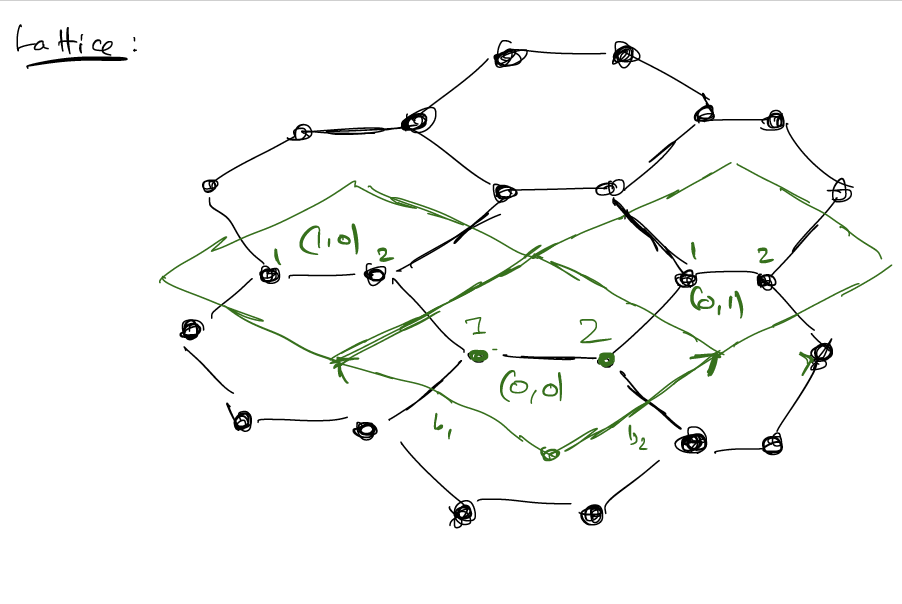

In [89]:
from IPython.display import Image, display
display(Image(filename="HoneycombLattice.png", width=800))

Let's implement the above honeycomb lattice. Each cell is indexed by its bravais lattice vectors --- (0,0), (0,1), (1,0) etc.---and in each cell there are two balls, 1 and 2

### Define the positions of the masses in the lattice

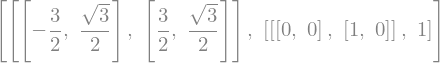

In [3]:
# the bravais lattice vectors for the honeycomb lattice
bravais = [
    [-sp.Rational(3, 2), sqrt3 / 2],
    [ sp.Rational(3, 2), sqrt3 / 2],
]
# the positions of the two balls in the unit cell of the honeycomb lattice
balls_honeycomb = [[0, 0], [1, 0]]

# Geometry starts with [primitive vectors, [positions, masses]].
hgeom = [bravais, [balls_honeycomb, 1]]
hgeom

The drawing functions visualize either one unit cell or a finite lattice patch.

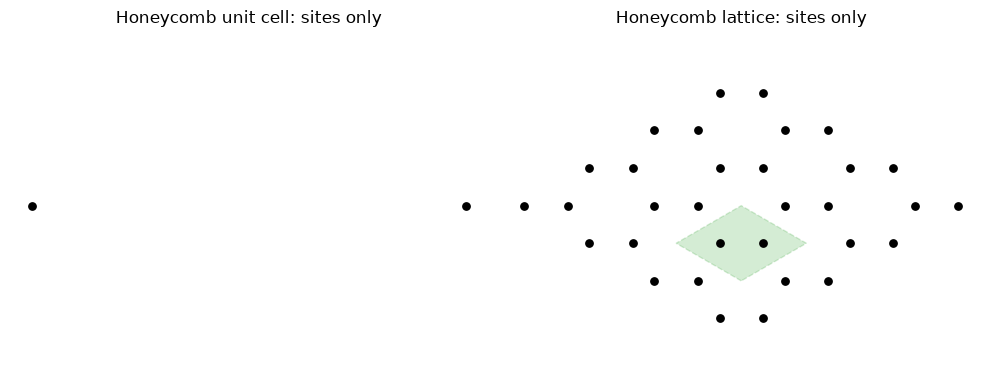

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(hgeom, ax=axes[0])
graphics.draw_lattice(
    hgeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Honeycomb unit cell: sites only")
axes[1].set_title("Honeycomb lattice: sites only")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Adding some Longitudinal springs

A longitudinal bond joins two balls, possibly in different unit cells. For
example, the following means “connect ball 2 in Bravais cell `(1, 0)` to ball
1 in cell `(0, 0)`.” The order is immaterial because this bond is symmetric.

In [6]:
example_spring = [[2, [1, 0]], [1, [0, 0]]]
example_spring

There are three such bonds in the honeycomb unit cell:

In [12]:
longitudinal_springs = [
    [[2, [1, 0]], [1, [0, 0]]],
    [[2, [0, 0]], [1, [0, 0]]],
    [[2, [0, 0]], [1, [0, 1]]],
]
longitudinal_springs

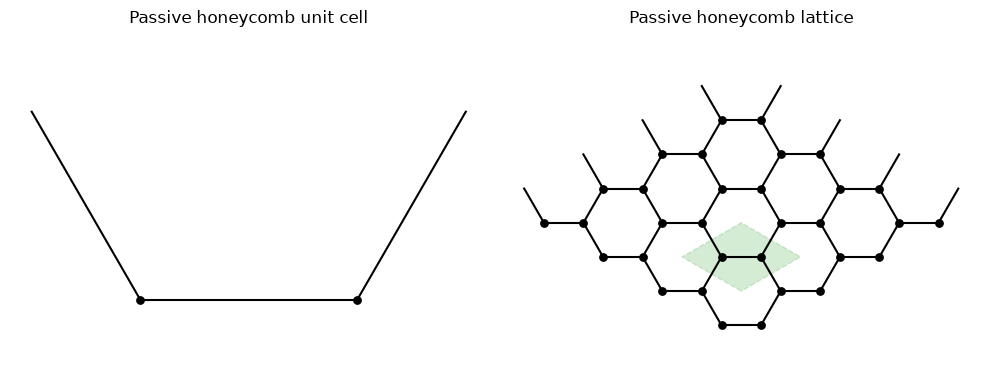

In [13]:
hgeom_passive = [
    bravais,
    [balls_honeycomb, 1],
    [["extension", "regular"], longitudinal_springs, k],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(hgeom_passive, ax=axes[0])
graphics.draw_lattice(
    hgeom_passive,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Passive honeycomb unit cell")
axes[1].set_title("Passive honeycomb lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Adding Some Angular Springs

A torsional bond is a triple of balls, with the bond residing on the middle
ball. The next example places a torsional spring between ball 1 in `(0, 0)`,
ball 2 in `(1, 0)`, and ball 1 in `(1, 1)`, centered on the middle reference.

In [9]:
example_torsion = [
    [1, [0, 0]],
    [2, [1, 0]],
    [1, [1, 1]],
]
example_torsion

There are six such torsional bonds in a honeycomb unit cell:

In [10]:
torsion_springs = [
    [[1, [0, 0]], [2, [1, 0]], [1, [1, 1]]],
    [[2, [0, 0]], [1, [0, 0]], [2, [1, 0]]],
    [[1, [0, 1]], [2, [0, 0]], [1, [0, 0]]],
    [[2, [1, 1]], [1, [0, 1]], [2, [0, 0]]],
    [[1, [1, 1]], [2, [1, 1]], [1, [0, 1]]],
    [[2, [1, 0]], [1, [1, 1]], [2, [1, 1]]],
]
torsion_springs

Spring groups carry a two-part label—for example, `("torsion", "regular")`—
followed by their connectivity and stiffness. Here $k$ is the longitudinal
stiffness and $\kappa$ is the torsional stiffness.

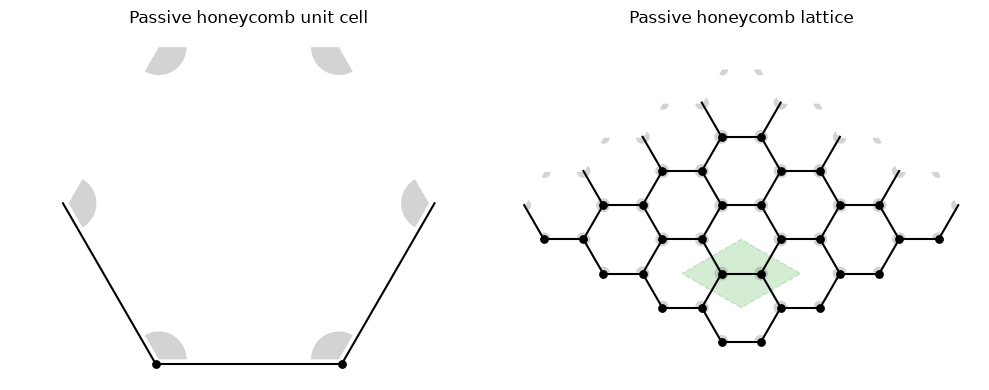

In [11]:
hgeom_passive = [
    bravais,
    [balls_honeycomb, 1],
    [["extension", "regular"], longitudinal_springs, k],
    [["torsion", "regular"], torsion_springs, kappa],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(hgeom_passive, ax=axes[0])
graphics.draw_lattice(
    hgeom_passive,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Passive honeycomb unit cell")
axes[1].set_title("Passive honeycomb lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Excercise 1 (5-10 mins)
- Mess around with the above code. Try rewiwiring the bonds, and revisualize. See what you get.

- Try drawing 2 other lattices: a Triangular lattice, and a square lattice


### Exercise 1a: Triangular

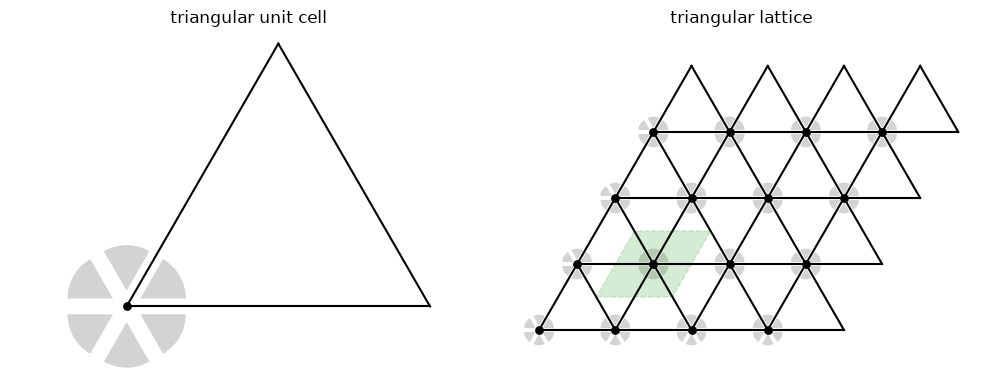

In [7]:
primitive_triangular = [
    [1, 0],
    [sp.cos(sp.pi / 3), sp.sin(sp.pi / 3)],
]
balls_triangular = [[0, 0]]

springs_triangular = [
    [[1, [0, 0]], [1, [1, 0]]],
    [[1, [1, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]]],
]

torsion_springs_tri = [
    [[1, [1, 0]], [1, [0, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]], [1, [-1, 1]]],
    [[1, [-1, 1]], [1, [0, 0]], [1, [-1, 0]]],
    [[1, [-1, 0]], [1, [0, 0]], [1, [0, -1]]],
    [[1, [0, -1]], [1, [0, 0]], [1, [1, -1]]],
    [[1, [1, -1]], [1, [0, 0]], [1, [1, 0]]],
]
torsion_springs_tri

Trigeom = [
    primitive_triangular,
    [balls_triangular, 1],
    [["extension", "regular"], springs_triangular, k],
    [["torsion", "regular"], torsion_springs_tri, kappa],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(Trigeom, ax=axes[0])
graphics.draw_lattice(
    Trigeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("triangular unit cell")
axes[1].set_title("triangular lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Exercise 1b: Square

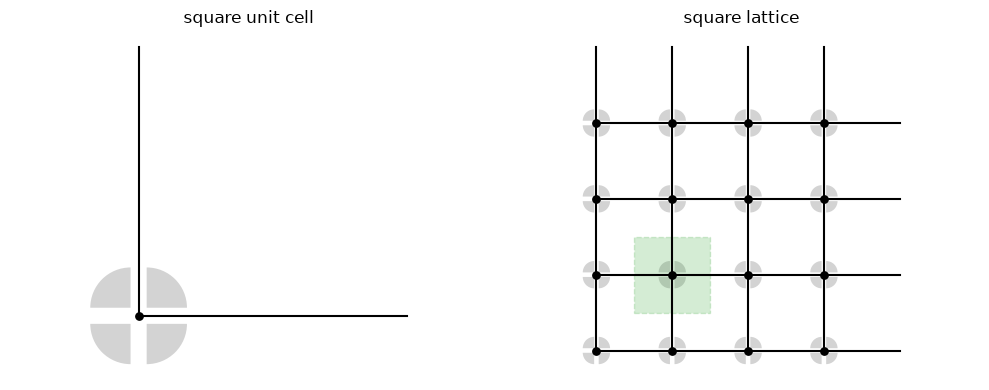

In [12]:
primitive_square = [
    [1, 0],
    [0,1]
]
balls_square = [[0, 0]]

springs_square = [
    [[1, [0, 0]], [1, [1, 0]]],
    [[1, [0, 0]], [1, [0, 1]]],

]
torsion_springs_square = [
    [[1, [1, 0]], [1, [0, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]], [1, [-1, 0]]],
    [[1, [-1, 0]], [1, [0, 0]], [1, [0, -1]]],
    [[1, [0, -1]], [1, [0, 0]], [1, [1, 0]]],
]
torsion_springs_square

SquareGeom = [
    primitive_square,
    [balls_square, 1],
    [["extension", "regular"], springs_square, k],
    [["torsion", "regular"], torsion_springs_square, kappa],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(SquareGeom, ax=axes[0])
graphics.draw_lattice(
    SquareGeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("square unit cell")
axes[1].set_title("square lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 1.2 Activating the lattice

The lattices above are passive, with linear and torsional rigidity. Active bonds
break Maxwell–Betti reciprocity [1]. A standard torsional spring obeys

$$\tau_i=-\kappa\,\delta\theta_i.$$

The nonreciprocal version implemented here couples neighboring angular bonds:

$$\tau_i=\kappa^a\left(\delta\theta_{i+1}-\delta\theta_{i-1}\right).$$

Implementing these in code is very easy! These non-reciprocal bonds comprise "cycles" of regular reciprocal bonds. E.g., a non-reciprocal torsional bond at node 0 comprises torisional data at nodes [-1,0,1] (say).  All we do is specify that cycle in the code.


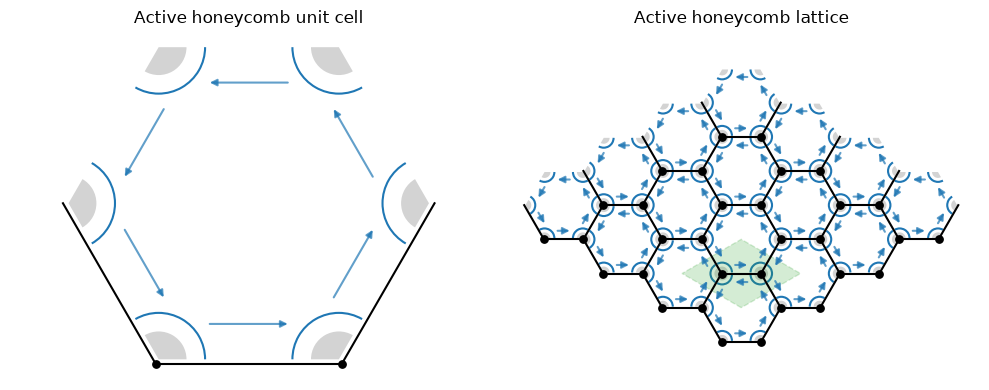

In [17]:
# The cyclic order of this list defines i-1 and i+1.
nonreciprocal_torsions = list(torsion_springs)

hgeom = [
    bravais,
    [balls_honeycomb, 1],
    [["extension", "regular"], longitudinal_springs, k],
    [["torsion", "regular"], torsion_springs, kappa],
    [["torsion", "data-sharing"], nonreciprocal_torsions, kappa_a],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(hgeom, ax=axes[0])
graphics.draw_lattice(
    hgeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Active honeycomb unit cell")
axes[1].set_title("Active honeycomb lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The blue arrows indicate the cyclic right- and left-neighbor relationships.

### Nonreciprocal longitudinal bonds

Reference [1] also introduces a longitudinal active bond with tension–length
relation

$$T_i=k^a\left(\delta L_{i+1}-\delta L_{i-1}\right).$$

Here is an example on a triangular lattice.

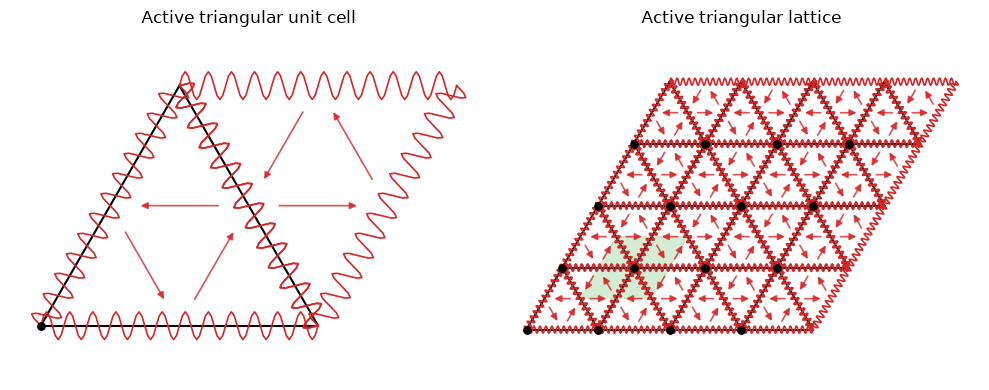

In [14]:
primitive_triangular = [
    [1, 0],
    [sp.cos(sp.pi / 3), sp.sin(sp.pi / 3)],
]
balls_triangular = [[0, 0]]

springs_triangular = [
    [[1, [0, 0]], [1, [1, 0]]],
    [[1, [1, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]]],
]
springs_triangular_ds1 = list(springs_triangular)
springs_triangular_ds2 = [
    [[1, [1, 0]], [1, [1, 1]]],
    [[1, [1, 1]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [1, 0]]],
]

Trigeom = [
    primitive_triangular,
    [balls_triangular, 1],
    [["extension", "regular"], springs_triangular, k],
    [["extension", "data-sharing"], springs_triangular_ds1, k_a],
    [["extension", "data-sharing"], springs_triangular_ds2, k_a],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(Trigeom, ax=axes[0])
graphics.draw_lattice(
    Trigeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Active triangular unit cell")
axes[1].set_title("Active triangular lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Excercise 2: A more complex active lattice, the Kekule-O lattice (10 mins)

The Kekulé-O lattice provides a more demanding test of the geometry,
torsion-generation, and rendering routines. Try making the lattice below:

![Experimental lattice](KekOLattice.png)

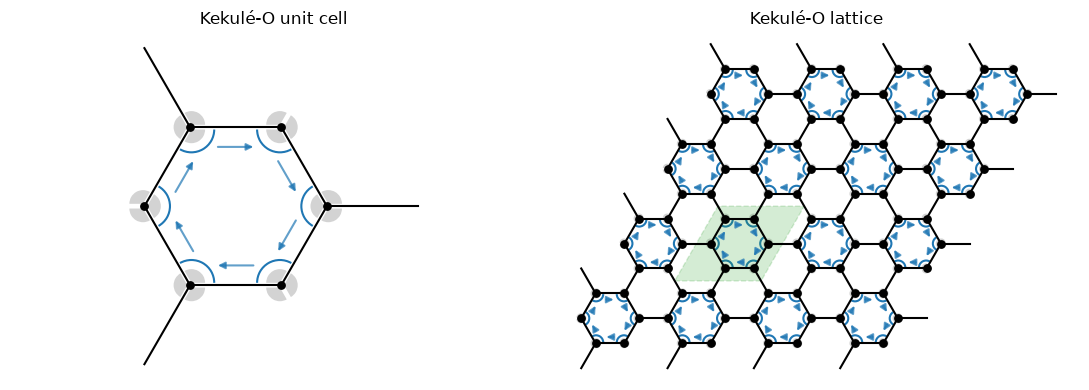

In [81]:
primitive_keko = [[3, 0], [sp.Rational(3, 2), 3 * sqrt3 / 2]]
balls_keko = [
    [1, 0],
    [sp.Rational(1, 2), sqrt3 / 2],
    [-sp.Rational(1, 2), sqrt3 / 2],
    [-1, 0],
    [-sp.Rational(1, 2), -sqrt3 / 2],
    [sp.Rational(1, 2), -sqrt3 / 2],
]

internal_keko = [
    [[i, [0, 0]], [i % 6 + 1, [0, 0]]]
    for i in range(1, 7)
]
external_keko = [
    [[1, [0, 0]], [4, [1, 0]]],
    [[3, [0, 0]], [6, [-1, 1]]],
    [[5, [0, 0]], [2, [0, -1]]],
]
springs_keko = internal_keko + external_keko
torsions_keko = odd.generate_all_tsprings(
    primitive_keko, balls_keko, springs_keko
)

reversed_ring = list(reversed([[i, [0, 0]] for i in range(1, 7)]))
torsions_keko_ds = []
for shift in range(6):
    rotated = reversed_ring[shift:] + reversed_ring[:shift]
    torsions_keko_ds.append(rotated[:3])

Kekogeom = [
    primitive_keko,
    [balls_keko, 1],
    [["extension", "regular"], springs_keko, k],
    [["torsion", "regular"], torsions_keko, kappa],
    [["torsion", "data-sharing"], torsions_keko_ds, kappa_a],
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
graphics.draw_unit_cell(Kekogeom, ax=axes[0])
graphics.draw_lattice(
    Kekogeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Kekulé-O unit cell")
axes[1].set_title("Kekulé-O lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# 2: Computing Vibrational Spectra and Elastic Moduli

We have now learnt how to specify an elastic lattice. How do we compute its vibrational structure? In general, we want to relate displacements of balls to forces on those balls. There is a linear relation between them, written as:

$$
F = - D \delta x = - C^t K C \delta x 
$$

where $F$ are forces, and $\delta x$ is a vector of all the ball displacements. The matrix $D$ is called the dynamical matrix, and encodes everything about the vibrations of the lattice and its elastic moduli.

The relation 

$$
D= C^t K C 
$$

breaks the dynamical matrix into 3 pieces, built from the *compatibility matrix* C, the *stiffness matrix* $K$, and the *equilibrium matrix $C^t$*, which turns out to be the transpose of the compatibility matrix. 

Here is what each piece does:

- $C$ relates ball displacements to changes to bond lengths (or angles, for torsional bonds):

$$
\begin{bmatrix}
\delta \mathbf{L}
\end{bmatrix}
=
{C}
\begin{bmatrix}
\delta \mathbf{x}
\end{bmatrix}
$$

- $K$ is a matrix of the stiffnesses of each bond. The product $KC$ gives the tensions in each bond.

$$
\begin{bmatrix}
T
\end{bmatrix}
=
{K C}
\begin{bmatrix}
\delta \mathbf{x}
\end{bmatrix}
$$

- $C^t$ finally maps the tensions in each bond to forces on each node.

$$
\begin{bmatrix}
F
\end{bmatrix}
=
-{C^t K C}
\begin{bmatrix}
\delta \mathbf{x}
\end{bmatrix}
$$

=
$$
\begin{bmatrix}
F
\end{bmatrix}
=
-D
\begin{bmatrix}
\delta \mathbf{x}
\end{bmatrix}
$$

 ## 2.1 A worked example of C 

For a unit equilateral triangle, choose the vertex positions

$$
\mathbf{x}_1=
\begin{bmatrix}
0\\
0
\end{bmatrix},
\qquad
\mathbf{x}_2=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\mathbf{x}_3=
\begin{bmatrix}
\frac{1}{2}\\
\frac{\sqrt{3}}{2}
\end{bmatrix}.
$$

Using the convention that $\hat{\mathbf r}_{ij}$ points from vertex $i$ to vertex $j$,

$$
\hat{\mathbf r}_{ij}
=
\frac{\mathbf{x}_j-\mathbf{x}_i}
{\left\lVert\mathbf{x}_j-\mathbf{x}_i\right\rVert},
$$

the unit bond vectors are

$$
\hat{\mathbf r}_{12}
=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\hat{\mathbf r}_{23}
=
\begin{bmatrix}
-\frac{1}{2}\\
\frac{\sqrt{3}}{2}
\end{bmatrix},
\qquad
\hat{\mathbf r}_{31}
=
\begin{bmatrix}
-\frac{1}{2}\\
-\frac{\sqrt{3}}{2}
\end{bmatrix}.
$$

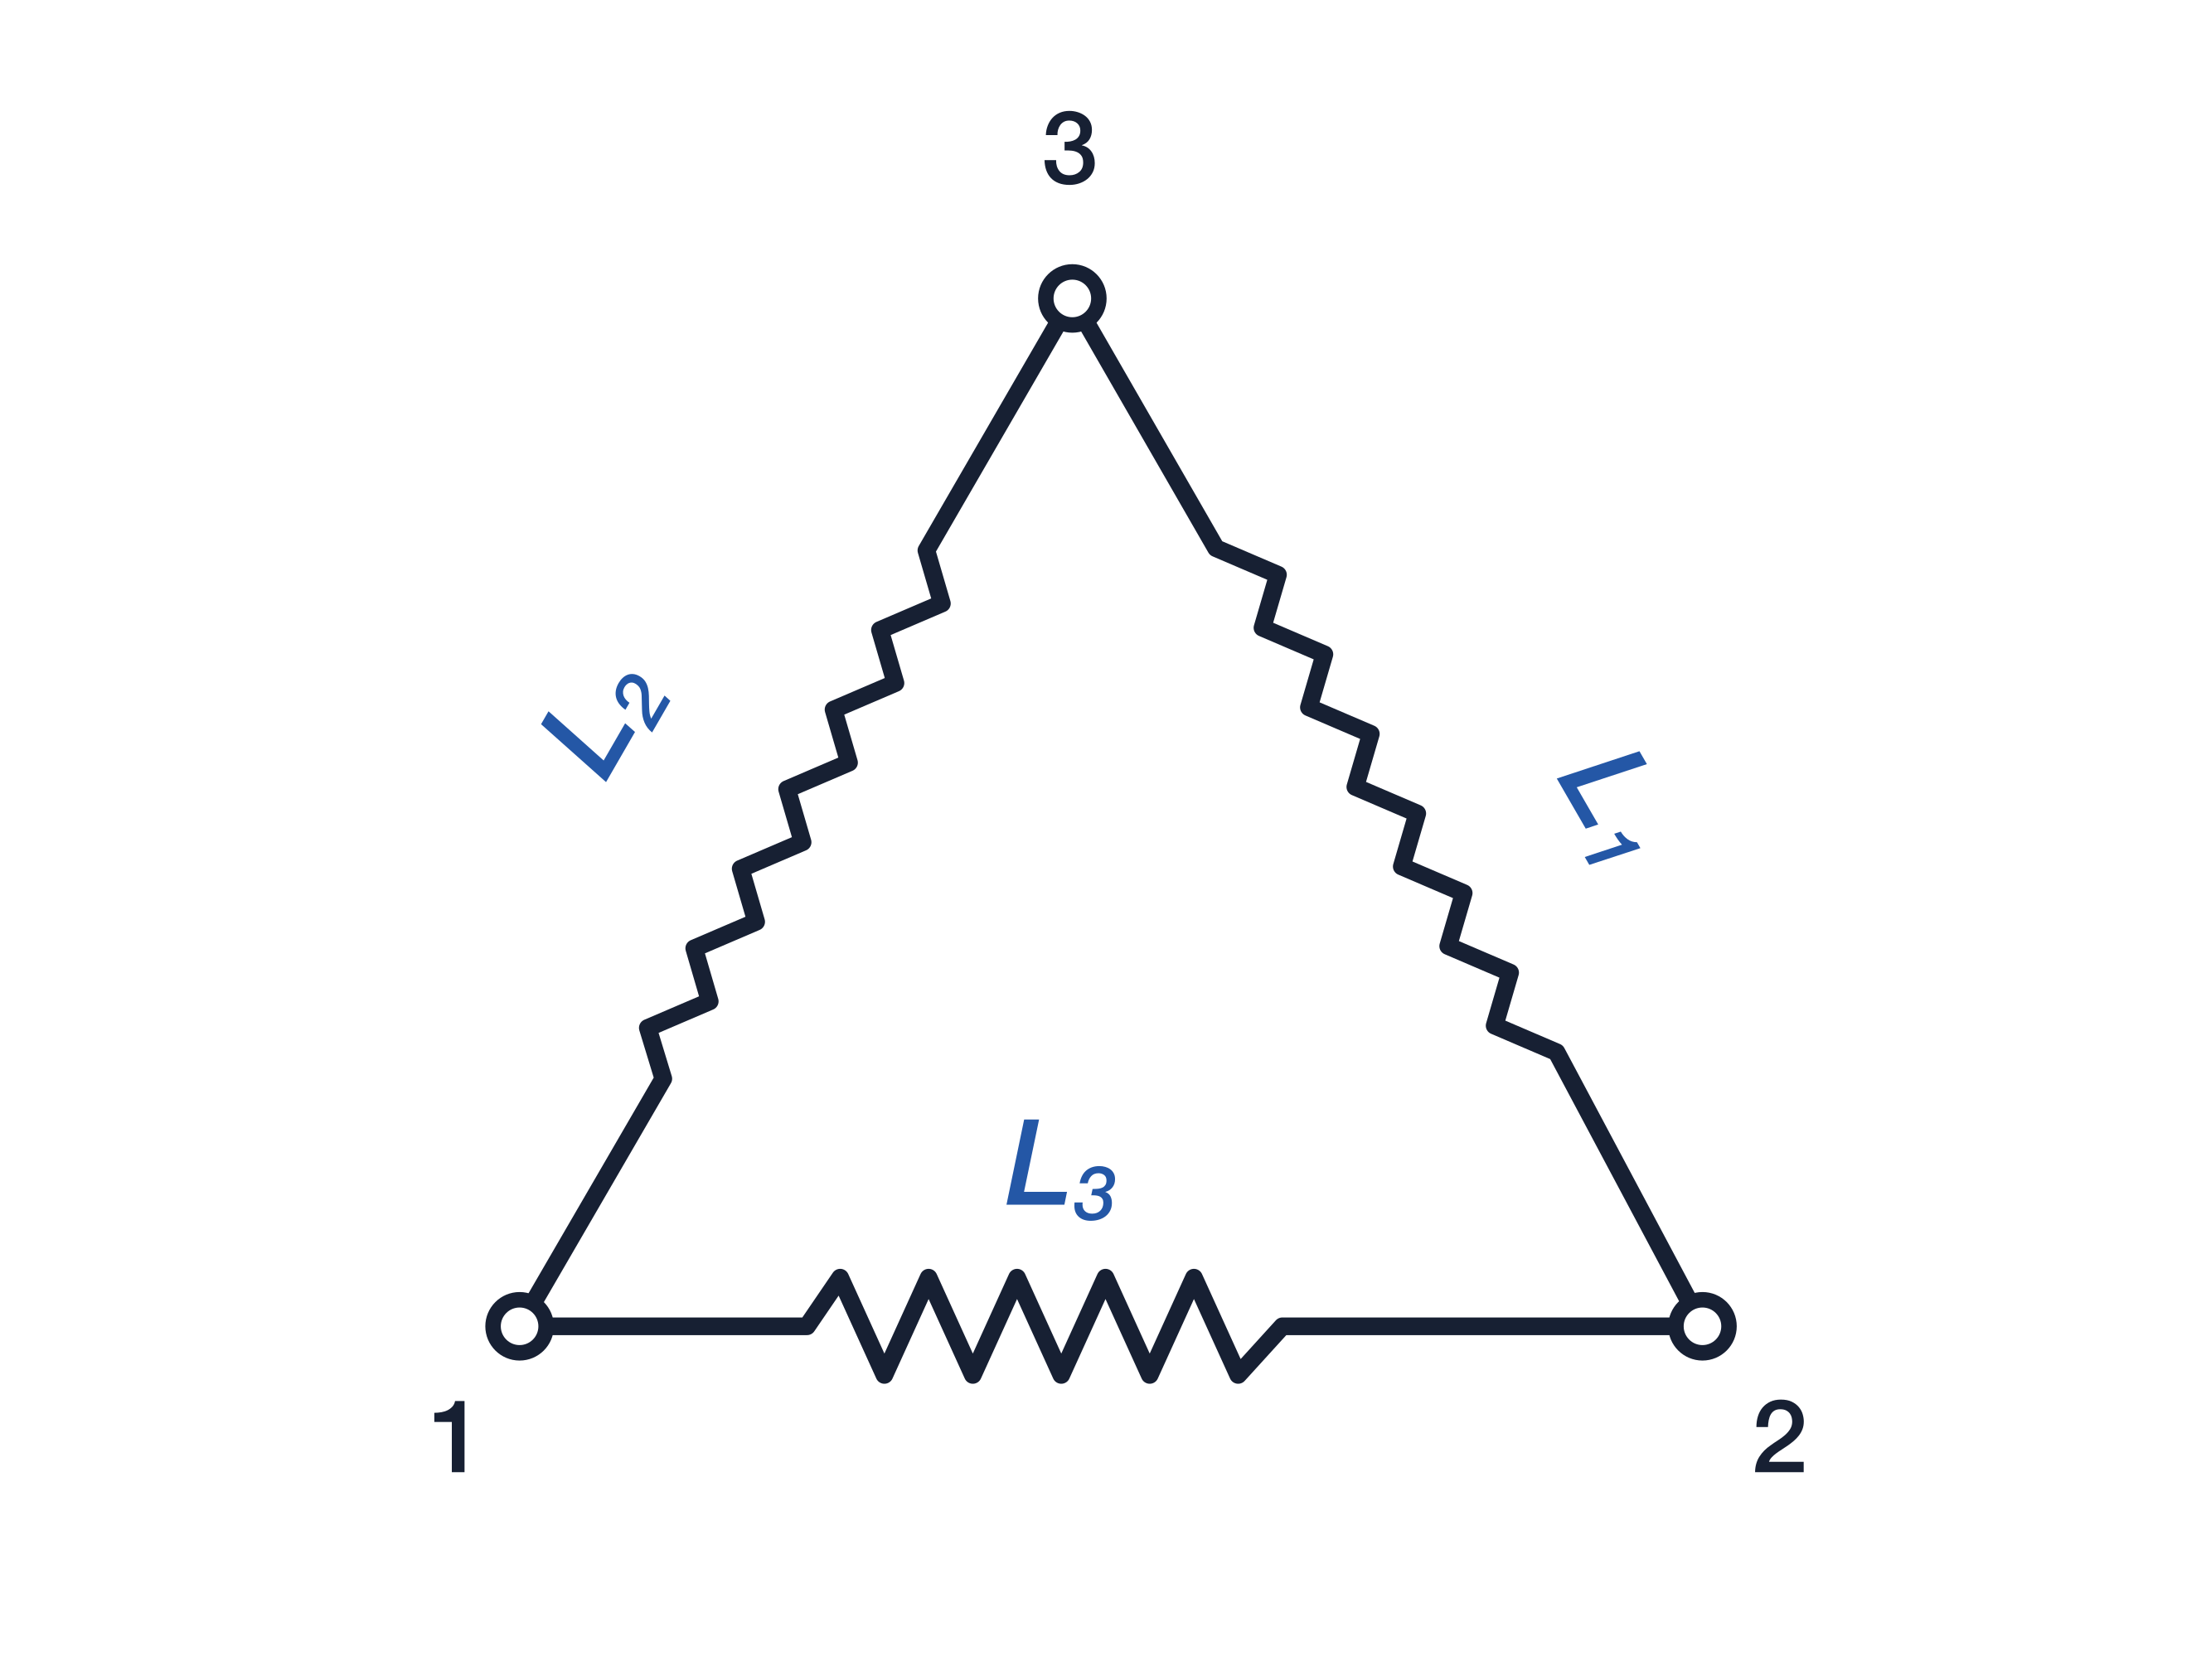

In [ ]:
from IPython.display import Image, display
display(Image(filename="Triangle.png", width=500))

To work out the structure of $C$, lets start from the displacement-length change map of a single spring. The linear length change is given by the expression:

$$
\delta L_\alpha = \hat{r}_{ij} \cdot (\delta \bm x_j - \delta \bm x_i)
$$


where $\hat r_{jj'}$ is the unit vector between the two balls in the spring. We can write this expression in a matrix form:

$$
\delta L_\alpha = 
\begin{pmatrix}
-\hat{\bm r}_{ij} & \hat{\bm r}_{ij}
\end{pmatrix}
\begin{pmatrix}
\delta \bm x_i \\
\delta \bm x_{j}
\end{pmatrix}.
$$

In this notation, I put vectors in the elements of the matrix, and every multiplication is a vector dot product (or if you like, I am writing block matrices). This turns out to be a very clean way of seperating geometry from indexing/book-keeping. I recommend it!

Now we just generalize across all the springs -  we slot all of the $\bm {r} $'s into a lattice. Here is an example for the triangle above:

$$
C =
\begin{bmatrix}
0 & -\hat{\mathbf r}_{23} & \hat{\mathbf r}_{23} \\
\hat{\mathbf r}_{31} & 0 & -\hat{\mathbf r}_{31} \\
-\hat{\mathbf r}_{12} & \hat{\mathbf r}_{12} & 0
\end{bmatrix}
\begin{bmatrix}
\delta \mathbf{x}_1 \\
\delta \mathbf{x}_2 \\
\delta \mathbf{x}_3
\end{bmatrix}
$$

If we want to, we can substitute in all the definitions of $\hat{r}$ - but to be honest, its more insightful *not* to. Still, here it is:



Writing each displacement as

$$
\delta\mathbf{x}_i
=
\begin{bmatrix}
\delta x_i\\
\delta y_i
\end{bmatrix},
$$

the compatibility matrix in component form is

$$
C
=
\begin{bmatrix}
0 & 0 &
\frac{1}{2} & -\frac{\sqrt{3}}{2} &
-\frac{1}{2} & \frac{\sqrt{3}}{2}
\\
-\frac{1}{2} & -\frac{\sqrt{3}}{2} &
0 & 0 &
\frac{1}{2} & \frac{\sqrt{3}}{2}
\\
-1 & 0 &
1 & 0 &
0 & 0
\end{bmatrix}.
$$

### Excercise 3 (5-10 mins)

- Try plugging the vector:
$$
\begin{bmatrix}
(\hat{\bm{r}}_{21}+\hat{\bm{r}}_{31})^\perp \\
(\hat{\bm{r}}_{12}+\hat{\bm{r}}_{32})^\perp \\
(\hat{\bm{r}}_{13}+\hat{\bm{r}}_{23})^\perp
\end{bmatrix}
$$

into the $C$ above, remembering that e.g. $r_{13}-r_{12} = r_{23}$ etc. The notation $\perp$ here means "the right-handed perpendicular vector to..." What do you get? What does it mean? What about an n-sided polygon? 

<details>
<summary><strong>Show answer</strong></summary>

 You get zero. This vector is in the kernel of $C$ - it is a soft mode, that causes no elastic distortions. In this case, it corresponds to rotating the triangle. In general, $C$ may have other many other soft modes, corresponding to internal floppy modes of deformation.
</details>

## 2.2 A worked example of $K$ 

This stiffness matrix $K$ relates bond length changes to the tensions in those bonds. For an ordinary lattice, it looks very simple - typically, its just diagonal: a bond changes its own length, and responds by feeling a tension:

$$
K =
\begin{bmatrix}
k & 0 & 0 \\
0 & k & 0 \\
0 & 0 & k
\end{bmatrix}
$$

### Excercise 4: Adding non-reciprocal bonds (5 mins)

Now suppose we wanted to add our non-reciprocal bonds into the mix. This is actually very easy - we do this by simply modifying the stiffness matrix to couple the lengths of neighboring bonds together. Take a look at our non-reciprocal force-extension law above. How should we modify $K$?

<details>
<summary><strong>Show answer</strong></summary>

$$
K =
\begin{bmatrix}
k & -k^{a} & k^{a} \\
k^{a} & k & -k^{a} \\
-k^{a} & k^{a} & k
\end{bmatrix}
$$
</details>

### Excercise 5 (5 mins)

- In a lattice with $N$ balls and $N_b$ bonds in $d$ dimensions, what are the general dimensions of the matrices $C$, $K$, and $D$? 
- When $k^a$ is zero, $K$ is symmetric. What does that mean for $D= C^t K C$ (hint, try taking the transpose of $D$)?
- By constrast, for nonzero $k^a$, what happens?

<details>
<summary><strong>Show answer</strong></summary>

- $C$ is $N_b \times d N$. $K$ is $N_b \times N_b$. $D$ is $d N \times dN$
- $D$ is symmetric too!
-  $D$ is no longer symmetric. We lose many of the expected properties of a symmetric (i.e. Hermitian) matrix - eigenvalues are no longer real, and eigenvectors are no longer orthogonal.
</details>

## 2.3 Going to Fourier Space

Everything above was for a finite lattice. But we can also work with infinite lattices which are periodic, by going to Fourier, a.k.a. reciprocal, a.k.a $q$-space. The calculational details are provided in the above references. I will summarize what happens, and how we can use it. We find that every matrix becomes indexed by a 2D wave vector $\bf {q}$, 

$$
D(q)= C^t(q) K(q) C(q) 
$$

where the dimensions of $D$, $C$, $K$ now correspond to the number of balls and bonds in the **unit cell**. For a unit cell with $n$ balls and $n_b$ bonds, $C$ is $n_b \times nd$, $K$ is $n_b \times n_b$, and $D$ is $nd \times nd$. 



### 2.3.1. Example - The passive triangular lattice

First, lets examine the dynamical matrix $D(q)$ for a triangular lattice just built from longitudinal springs

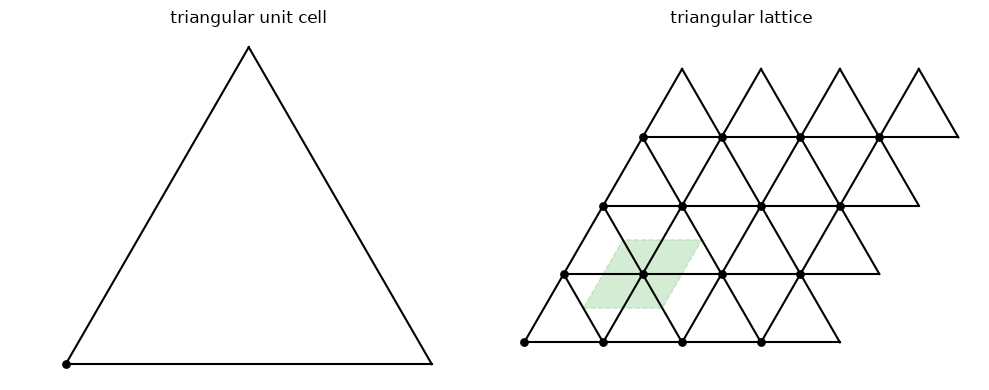

In [72]:
primitive_triangular = [
    [1, 0],
    [sp.cos(sp.pi / 3), sp.sin(sp.pi / 3)],
]
balls_triangular = [[0, 0]]

springs_triangular = [
    [[1, [0, 0]], [1, [1, 0]]],
    [[1, [1, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]]],
]

Trigeom = [
    primitive_triangular,
    [balls_triangular, 1],
    [["extension", "regular"], springs_triangular, k],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(Trigeom, ax=axes[0])
graphics.draw_lattice(
    Trigeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("triangular unit cell")
axes[1].set_title("triangular lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

To get the code to calculate $D(q)$ we feed in the lattice itself, and call a built-in function:

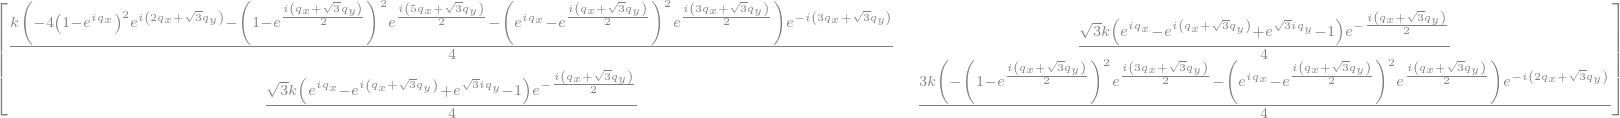

In [74]:
# we tell the code what the Bravais lattice vectors are, and what the geometry is.
#  This is a bit redundant because we already put these vectors in to the geometry, but sometimes its easier to right the phase factors without the BZ vectors
physical_wavevector = sp.Matrix([qx, qy])
q_in = [
    physical_wavevector.dot(sp.Matrix(vector))
    for vector in Trigeom[0]
]
q_in

dynamical_physical = odd.dynamical_matrix(Trigeom, q_in)
display(dynamical_physical)


Unfortunately, sympy isn't great at boiling down these exponential expressions. We can give it some help by forcing to to rewrite the exponetials with cosines

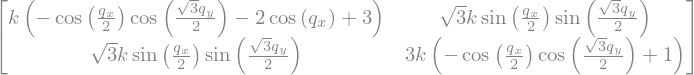

In [75]:
dynamical_physical = odd.dynamical_matrix(Trigeom, q_in, simplify=False)
dynamical_physical = dynamical_physical.applyfunc(
    lambda e: sp.simplify(sp.trigsimp(e.rewrite(sp.cos)))
)
display(dynamical_physical)

much nicer!

### Excercise 6 (5-10 mins) - What does it mean?

- What is the interpretation of $D(q)$? for a given $q$, what is $D(q)$ telling us, intuitively?
-  E.g. What does $D(0)$ mean?

<details>
<summary><strong>Show answer</strong></summary>

- For a given wave, of periodicity $q$, its telling us what the forces on the nodes in the unit cell are. For a triangular lattice, there is only a single node, and only a single force vector.
</details>

### Getting the vibrational spectrum

We can find the vibrational modes of the lattice by taking the eiqenvalues, $\lambda(q)$, of $D$, and plotting them over the Brillouin  zone of the lattice

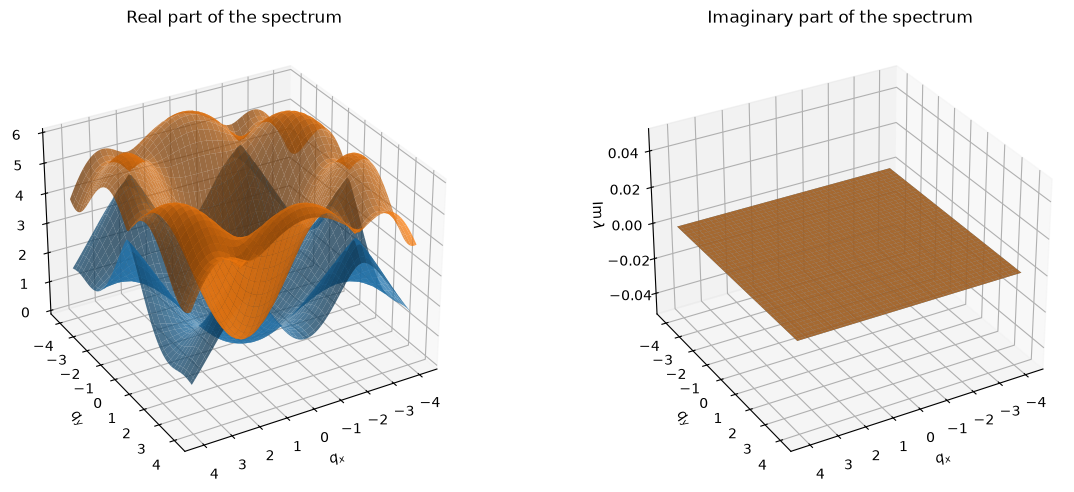

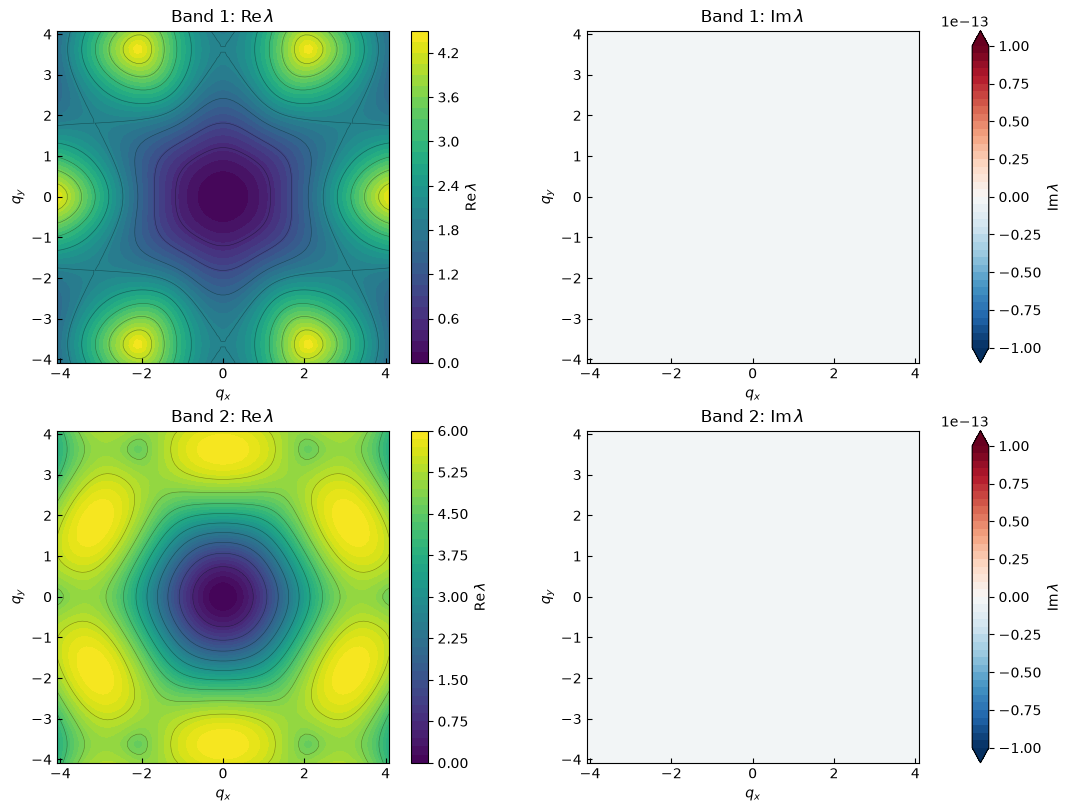

In [82]:
# Diagonlize, Add a BZ plot, and an eigenvalue plot
import numpy as np
import matplotlib.pyplot as plt


##### some settings you can play with! ####
kain = 0.0 # the activity value. I set it to 0 initially
view_angles = (30,60) # from the side. other options you could try are   "top":    (90, -90),  "front":  (0, -90),    "side":   (0, 0),
view = "side"       # "angled", "top", "front", or "side"
projection = "persp"  # "persp" or "ortho"
elevation, azimuth = view_angles
###########################################


# Substitute numerical parameter values before lambdifying.
D_numeric = sp.lambdify(
    (qx, qy),
    dynamical_physical.subs({
        k: 1.0
    }),
    modules="numpy",
)

# A few rectangles in Q space, so we can see the periodicity of the spectrum.
xlim=1.3*np.pi 
ylim=1.3*np.pi

qx_values = np.linspace(-xlim, xlim, 80)
qy_values = np.linspace(-ylim, ylim, 80)
QX, QY = np.meshgrid(qx_values, qy_values)

number_of_bands = dynamical_physical.shape[0]
eigenvalues = np.empty((*QX.shape, number_of_bands), dtype=complex)

for iy in range(len(qy_values)):
    for ix in range(len(qx_values)):
        matrix = np.asarray(
            D_numeric(qx_values[ix], qy_values[iy]),
            dtype=complex,
        )

        values = np.linalg.eigvals(matrix) # for each q, get the eignvalues \lambda(q)

        # Consistent ordering for plotting.
        order = np.lexsort((values.imag, values.real))
        eigenvalues[iy, ix] = values[order]

# First up, some 3D plots. Plot real and imaginary parts.
fig = plt.figure(figsize=(13, 5))

ax_real = fig.add_subplot(121, projection="3d")
ax_imag = fig.add_subplot(122, projection="3d")

for band in range(number_of_bands):
    ax_real.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].real,
        alpha=0.75,
    )

    ax_imag.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].imag,
        alpha=0.75,
    )


for ax in (ax_real, ax_imag):
    ax.view_init(
        elev=elevation,
        azim=azimuth,
    )
    ax.set_proj_type(projection)

ax_real.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Re}\,\lambda$",
    title="Real part of the spectrum",
)

ax_imag.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Im}\,\lambda$",
    title="Imaginary part of the spectrum",
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    number_of_bands,
    2,
    figsize=(11, 4 * number_of_bands),
    constrained_layout=True,
    squeeze=False,
)

for band in range(number_of_bands):
    real_part = eigenvalues[:, :, band].real
    imag_part = eigenvalues[:, :, band].imag

    # Real part
    real_plot = axes[band, 0].contourf(
        QX,
        QY,
        real_part,
        levels=40,
        cmap="viridis",
    )

    axes[band, 0].contour(
        QX,
        QY,
        real_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        real_plot,
        ax=axes[band, 0],
        label=r"$\mathrm{Re}\,\lambda$",
    )

    # Use a symmetric colour scale for the imaginary part.
    imag_limit = np.max(np.abs(imag_part))

    if imag_limit > 0:
        imag_levels = np.linspace(-imag_limit, imag_limit, 41)
    else:
        imag_levels = 40

    imag_plot = axes[band, 1].contourf(
        QX,
        QY,
        imag_part,
        levels=imag_levels,
        cmap="RdBu_r",
        extend="both",
    )

    axes[band, 1].contour(
        QX,
        QY,
        imag_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        imag_plot,
        ax=axes[band, 1],
        label=r"$\mathrm{Im}\,\lambda$",
    )

    axes[band, 0].set_title(
        rf"Band {band + 1}: $\mathrm{{Re}}\,\lambda$"
    )
    axes[band, 1].set_title(
        rf"Band {band + 1}: $\mathrm{{Im}}\,\lambda$"
    )

    for ax in axes[band]:
        ax.set_xlabel(r"$q_x$")
        ax.set_ylabel(r"$q_y$")
        ax.set_aspect("equal")
        ax.tick_params(direction="in")

plt.show()



### Excercise 7 (5-10 mins) - What does it mean?

- What do you notice about the spectrum as $q \rightarrow 0 $. In particular, what do you notice about (i) the value of the countours and (ii) the shape of the contours. What is that telling us about the vibrations of the lattice?
- There are 2 bands. Are they the same, or different? What do these two bands represent? In 1D, how many bands would there be? And in 3D?
- What do you notice about $\mathrm{Im} \lambda(q)$?

<details>
<summary><strong>Show answer</strong></summary>

- It also goes to 0. These are the long wavelength vibrations of the lattice, that cost very little energy - the phonons.
- They are different! They are the 2 vibrational waves of a lattice, the shear wave and the dilational wave. These 2 waves have different dispersion, speed etc. So the two bands look different.
- There is 1 band per degree of freedom in the unit cell, i.e. there are $n d$ bands.
- $\mathrm{Im} \lambda(q)= 0$, because the dynamical matrix is Hermitian.
</details>

### 2.3.4 Adding active bonds

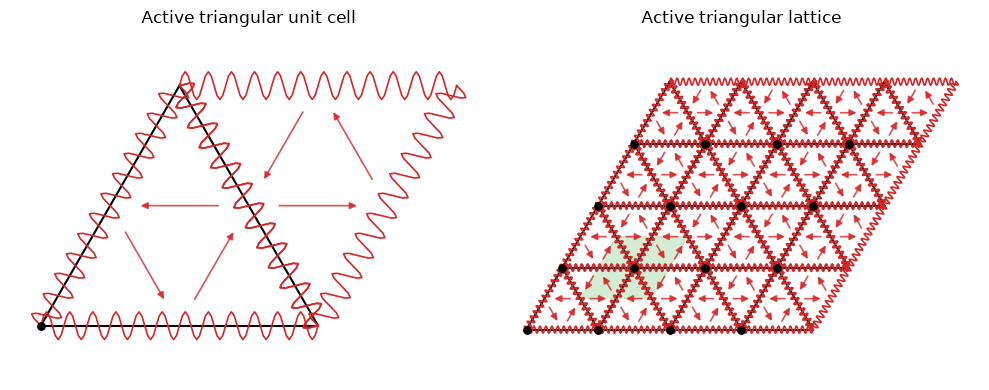

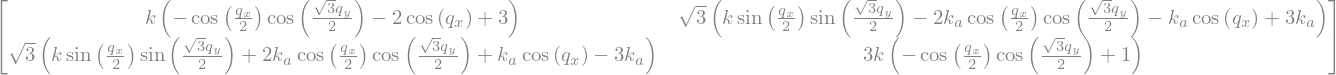

In [83]:
primitive_triangular = [
    [1, 0],
    [sp.cos(sp.pi / 3), sp.sin(sp.pi / 3)],
]
balls_triangular = [[0, 0]]

springs_triangular = [
    [[1, [0, 0]], [1, [1, 0]]],
    [[1, [1, 0]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [0, 0]]],
]
springs_triangular_ds1 = list(springs_triangular)
springs_triangular_ds2 = [
    [[1, [1, 0]], [1, [1, 1]]],
    [[1, [1, 1]], [1, [0, 1]]],
    [[1, [0, 1]], [1, [1, 0]]],
]

Trigeom = [
    primitive_triangular,
    [balls_triangular, 1],
    [["extension", "regular"], springs_triangular, k],
    [["extension", "data-sharing"], springs_triangular_ds1, k_a],
    [["extension", "data-sharing"], springs_triangular_ds2, k_a],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(Trigeom, ax=axes[0])
graphics.draw_lattice(
    Trigeom,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Active triangular unit cell")
axes[1].set_title("Active triangular lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
physical_wavevector = sp.Matrix([qx, qy])
q_in = [
    physical_wavevector.dot(sp.Matrix(vector))
    for vector in Trigeom[0]
]
q_in

dynamical_physical = odd.dynamical_matrix(Trigeom, q_in)
#display(dynamical_physical)
dynamical_physical = odd.dynamical_matrix(Trigeom, q_in, simplify=False)
dynamical_physical = dynamical_physical.applyfunc(
    lambda e: sp.simplify(sp.trigsimp(e.rewrite(sp.cos)))
)
display(dynamical_physical)



### Excercise 8 (5-10 mins) - What does it mean?

- What happened to the structure of $D(q)$, in comparison to the passive lattice? 

<details>
<summary><strong>Show answer</strong></summary>

- The $ k_a $ terms precisely correspond to the non-Hermitian part of the $D(q)$.

</details>

/Users/jackbinysh/miniconda3/envs/UKMMN/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:184: RuntimeWarning: overflow encountered in dot
  product = np.dot(axes.M, vec)


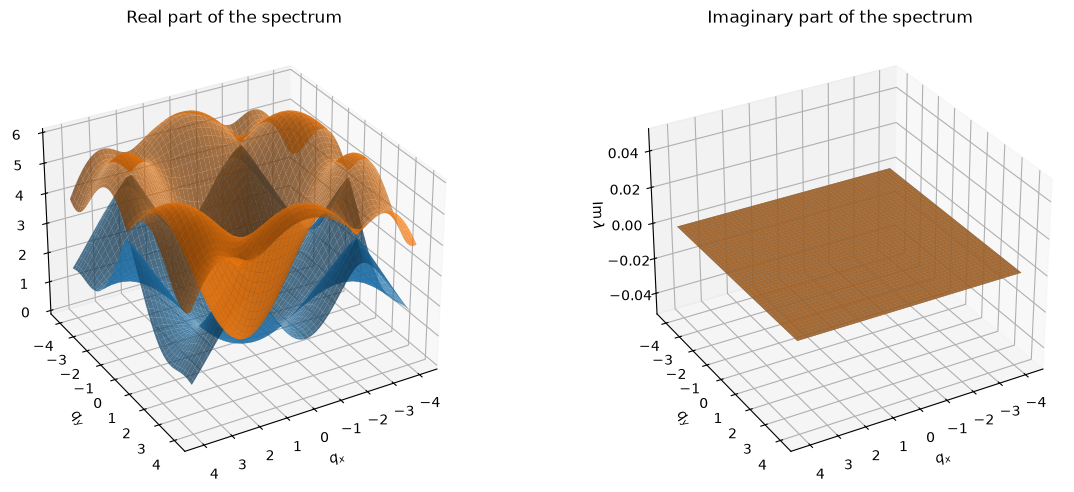

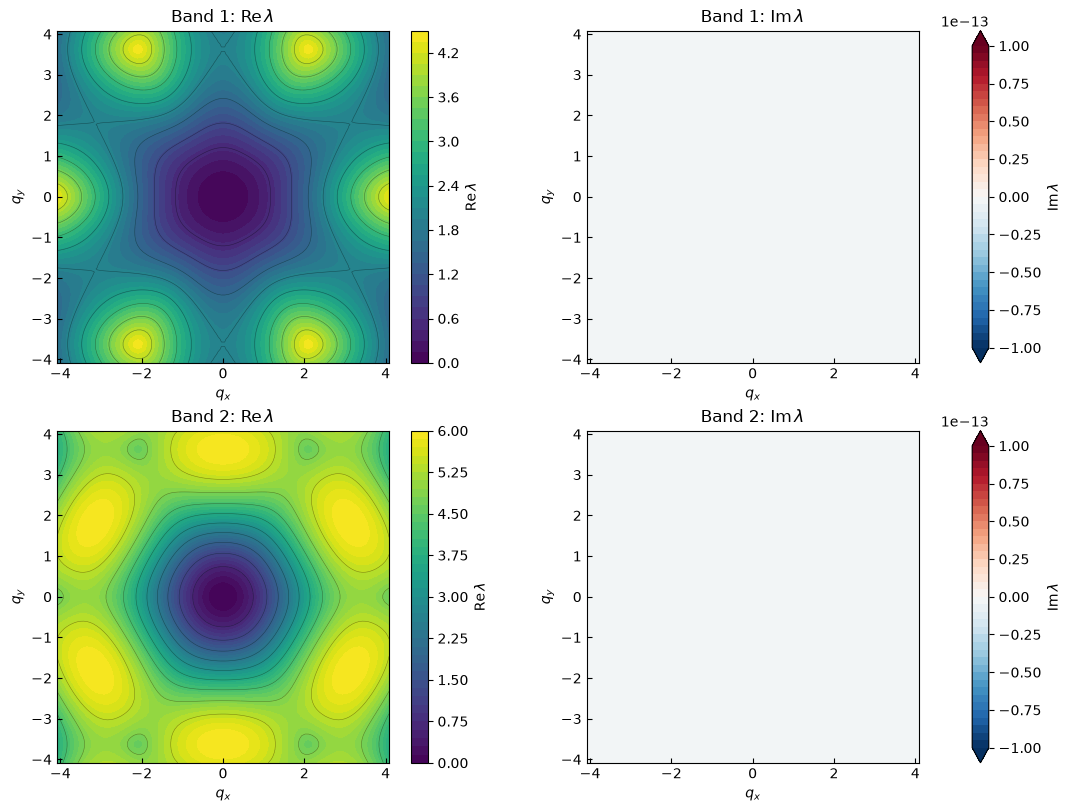

In [84]:
# Diagonlize, Add a BZ plot, and an eigenvalue plot
import numpy as np
import matplotlib.pyplot as plt

##### some settings you can play with! ####
kain = 0.0 # the activity value. I set it to 0 initially
view_angles = (30,60) # from the side. other options you could try are   "top":    (90, -90),  "front":  (0, -90),    "side":   (0, 0),
view = "side"       # "angled", "top", "front", or "side"
projection = "persp"  # "persp" or "ortho"
elevation, azimuth = view_angles
###########################################


#### The code that draws the band structure ######

# Dont worry about this  function initially - it orders the bands by their imaginary parts - try removing it below and see what happens!
def order_bands_by_imaginary_sign(unordered_eigenvalues, tol=1e-10):
    """
    Order a two-band spectrum by the sign of Im(lambda).

    Band 0: negative imaginary part
    Band 1: positive imaginary part

    At points where both imaginary parts vanish, use the real
    parts as a deterministic tie-breaker.
    """
    values = np.asarray(unordered_eigenvalues, dtype=complex)

    if values.shape[-1] != 2:
        raise ValueError(
            "Imaginary-sign ordering expects exactly two bands."
        )

    ordered = np.empty_like(values)

    for index in np.ndindex(values.shape[:-1]):
        local_values = values[index]

        imaginary_key = local_values.imag.copy()
        imaginary_key[np.abs(imaginary_key) < tol] = 0.0

        # Primary key: imaginary part.
        # Tie-breaker: real part.
        order = np.lexsort(
            (local_values.real, imaginary_key)
        )

        ordered[index] = local_values[order]

    return ordered


# Substitute numerical parameter values before lambdifying.
D_numeric = sp.lambdify(
    (qx, qy),
    dynamical_physical.subs({
        k: 1.0,
        k_a: kain # a bit of activity
    }),
    modules="numpy",
)

# A few rectangles in Q space, so we can see the periodicity of the spectrum.
xlim=1.3*np.pi 
ylim=1.3*np.pi

qx_values = np.linspace(-xlim, xlim, 100)
qy_values = np.linspace(-ylim, ylim, 100)
QX, QY = np.meshgrid(qx_values, qy_values)

number_of_bands = dynamical_physical.shape[0]
eigenvalues = np.empty((*QX.shape, number_of_bands), dtype=complex)

for iy in range(len(qy_values)):
    for ix in range(len(qx_values)):
        matrix = np.asarray(
            D_numeric(qx_values[ix], qy_values[iy]),
            dtype=complex,
        )

        values = np.linalg.eigvals(matrix) # for each q, get the eignvalues \lambda(q)

        # Consistent ordering for plotting.
        order = np.lexsort((values.imag, values.real))
        eigenvalues[iy, ix] = values[order]


eigenvalues = order_bands_by_imaginary_sign(eigenvalues)

# First up, some 3D plots. Plot real and imaginary parts.
fig = plt.figure(figsize=(13, 5))

ax_real = fig.add_subplot(121, projection="3d")
ax_imag = fig.add_subplot(122, projection="3d")

for band in range(number_of_bands):
    ax_real.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].real,
        alpha=0.75,
    )

    ax_imag.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].imag,
        alpha=0.75,
    )

for ax in (ax_real, ax_imag):
    ax.view_init(
        elev=elevation,
        azim=azimuth,
    )
    ax.set_proj_type(projection)

ax_real.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Re}\,\lambda$",
    title="Real part of the spectrum",
)

ax_imag.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Im}\,\lambda$",
    title="Imaginary part of the spectrum",
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    number_of_bands,
    2,
    figsize=(11, 4 * number_of_bands),
    constrained_layout=True,
    squeeze=False,
)

for band in range(number_of_bands):
    real_part = eigenvalues[:, :, band].real
    imag_part = eigenvalues[:, :, band].imag

    # Real part
    real_plot = axes[band, 0].contourf(
        QX,
        QY,
        real_part,
        levels=40,
        cmap="viridis",
    )

    axes[band, 0].contour(
        QX,
        QY,
        real_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        real_plot,
        ax=axes[band, 0],
        label=r"$\mathrm{Re}\,\lambda$",
    )

    # Use a symmetric colour scale for the imaginary part.
    imag_limit = np.max(np.abs(imag_part))

    if imag_limit > 0:
        imag_levels = np.linspace(-imag_limit, imag_limit, 41)
    else:
        imag_levels = 40

    imag_plot = axes[band, 1].contourf(
        QX,
        QY,
        imag_part,
        levels=imag_levels,
        cmap="RdBu_r",
        extend="both",
    )

    axes[band, 1].contour(
        QX,
        QY,
        imag_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        imag_plot,
        ax=axes[band, 1],
        label=r"$\mathrm{Im}\,\lambda$",
    )

    axes[band, 0].set_title(
        rf"Band {band + 1}: $\mathrm{{Re}}\,\lambda$"
    )
    axes[band, 1].set_title(
        rf"Band {band + 1}: $\mathrm{{Im}}\,\lambda$"
    )

    for ax in axes[band]:
        ax.set_xlabel(r"$q_x$")
        ax.set_ylabel(r"$q_y$")
        ax.set_aspect("equal")
        ax.tick_params(direction="in")

plt.show()

#### Excercise 11 (10 mins): Playing with parameters

- Vary $k_a$ slowly, and watch what happens to the real and imaginary parts of the eigenvalues. Where do the eigenvalues become complex first? What happens after that, and where do the bands end up at large $k_a$?

<details>
<summary><strong>Show answer</strong></summary>

- The imaginary values appear at high $q$ first, and progressively invade the BZ.
- For a given $q$, when the eigenvalues pick up an imaginary part, their real part degenerates. This eventually happens acorss the entire BZ, at which point the real parts of the bands are totally degenerate! At each $q$, this splitting/degeneration is called an exceptional point/exceptional transition. Google some pictures of them!

</details>



#### Excercise 12 (10 mins): Plotting the eigenvalues on the complex plane

Try sampling the Brillouin zone above, and plotting all of the eigenvectors on the complex plane its, i.e. plot $Re (\lambda)$ against $Im (\lambda)$

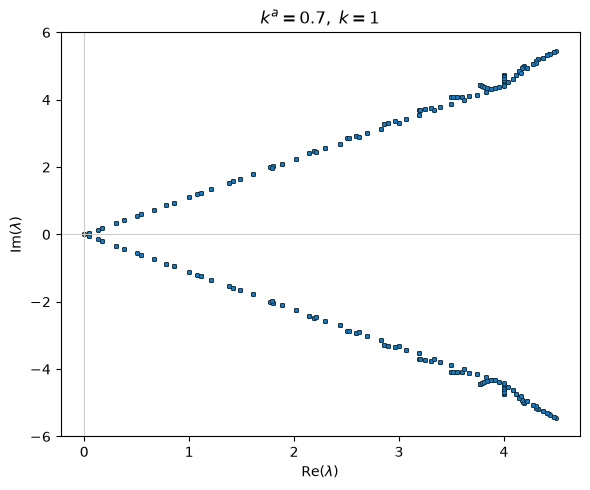

In [71]:
dynamical_phase = odd.dynamical_matrix(Trigeom, (qx, qy))
dm_numeric = sp.lambdify(
    (qx, qy, k, k_a), dynamical_phase, modules="numpy"
)

##### the ka value you can vary#####
k_a_input = 0.7
###################################

N_x = N_y = 30 # 30 samples across the Brillouin zone.
k_input = 1.0 # the spring constant
q_x_values = np.linspace(0, 2 * np.pi, N_x + 1)
q_y_values = np.linspace(0, 2 * np.pi, N_y + 1)

eigenvalues = []
for q_x_value in q_x_values:
    for q_y_value in q_y_values:
        matrix = np.asarray(
            dm_numeric(q_x_value, q_y_value, k_input, k_a_input),
            dtype=complex,
        )
        eigenvalues.extend(np.linalg.eigvals(matrix))
eigenvalues = np.asarray(eigenvalues)


fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    eigenvalues.real,
    eigenvalues.imag,
    s=10,
    color="#1f77b4",
    edgecolors="black",
    linewidths=0.25,
)
ax.set_xlabel(r"$\mathrm{Re}(\lambda)$")
ax.set_ylabel(r"$\mathrm{Im}(\lambda)$")
ax.set_title(fr"$k^a={k_a_input:g},\; k={k_input:g}$")
ax.axhline(0, color="0.8", linewidth=0.8)
ax.axvline(0, color="0.8", linewidth=0.8)
plt.tight_layout()
plt.show()

### 2.3.2. Excercise 13 (10 mins) The Honeycomb lattice

Repeat the above analysis for the Honeycomb lattice made of longitudinal bonds - many interesting things happen in this example! Below is the code for a passive lattice. I invite you to try and activate it.

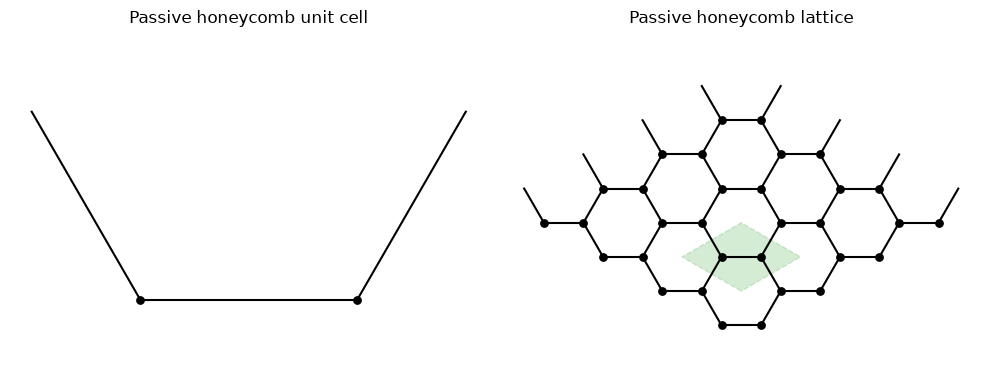

In [42]:
# the bravais lattice vectors for the honeycomb lattice
bravais = [
    [-sp.Rational(3, 2), sqrt3 / 2],
    [ sp.Rational(3, 2), sqrt3 / 2],
]
# the positions of the two balls in the unit cell of the honeycomb lattice
balls_honeycomb = [[0, 0], [1, 0]]

# Geometry starts with [primitive vectors, [positions, masses]].
hgeom = [bravais, [balls_honeycomb, 1]]
hgeom

longitudinal_springs = [
    [[2, [1, 0]], [1, [0, 0]]],
    [[2, [0, 0]], [1, [0, 0]]],
    [[2, [0, 0]], [1, [0, 1]]],
]
longitudinal_springs

hgeom_passive = [
    bravais,
    [balls_honeycomb, 1],
    [["extension", "regular"], longitudinal_springs, k],
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
graphics.draw_unit_cell(hgeom_passive, ax=axes[0])
graphics.draw_lattice(
    hgeom_passive,
    lattice_cells=list(product(range(4), repeat=2)),
    ax=axes[1],
)
axes[0].set_title("Passive honeycomb unit cell")
axes[1].set_title("Passive honeycomb lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

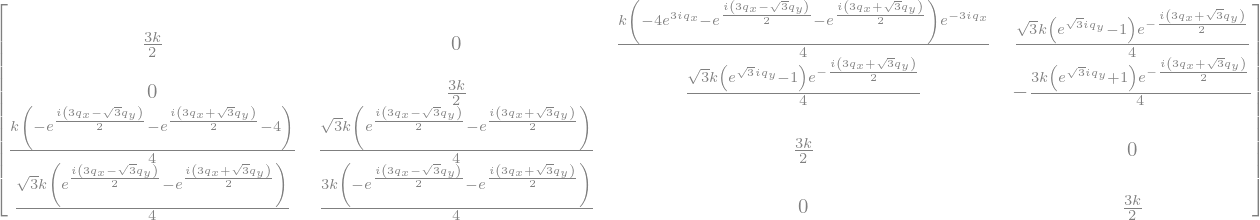

In [35]:
physical_wavevector = sp.Matrix([qx, qy])
q_in = [
    physical_wavevector.dot(sp.Matrix(vector))
    for vector in hgeom_passive[0]
]
q_in

dynamical_physical = odd.dynamical_matrix(hgeom_passive, q_in)
display(dynamical_physical)

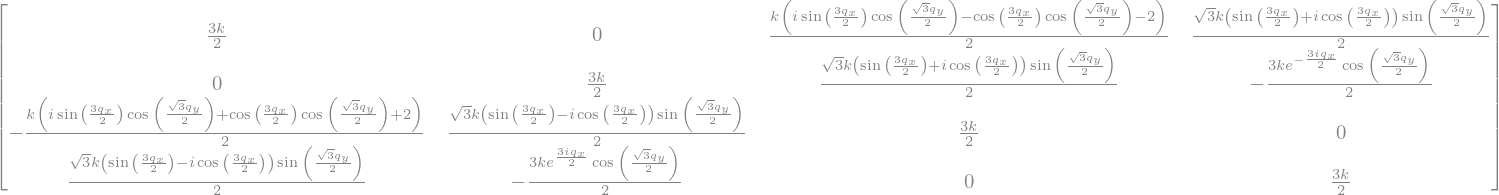

In [36]:
dynamical_physical = odd.dynamical_matrix(hgeom_passive, q_in, simplify=False)
dynamical_physical = dynamical_physical.applyfunc(
    lambda e: sp.simplify(sp.trigsimp(e.rewrite(sp.cos)))
)
display(dynamical_physical)

/Users/jackbinysh/miniconda3/envs/UKMMN/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:184: RuntimeWarning: overflow encountered in dot
  product = np.dot(axes.M, vec)


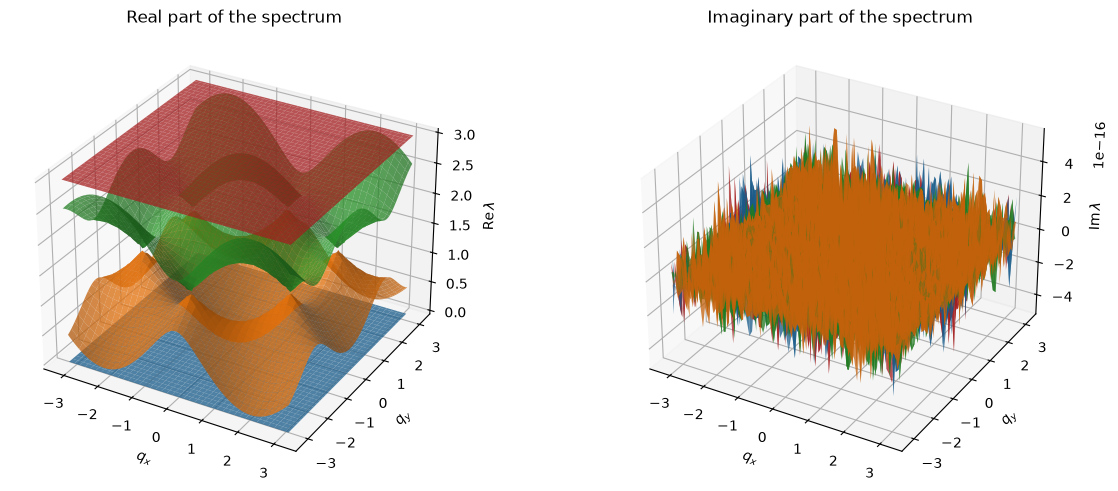

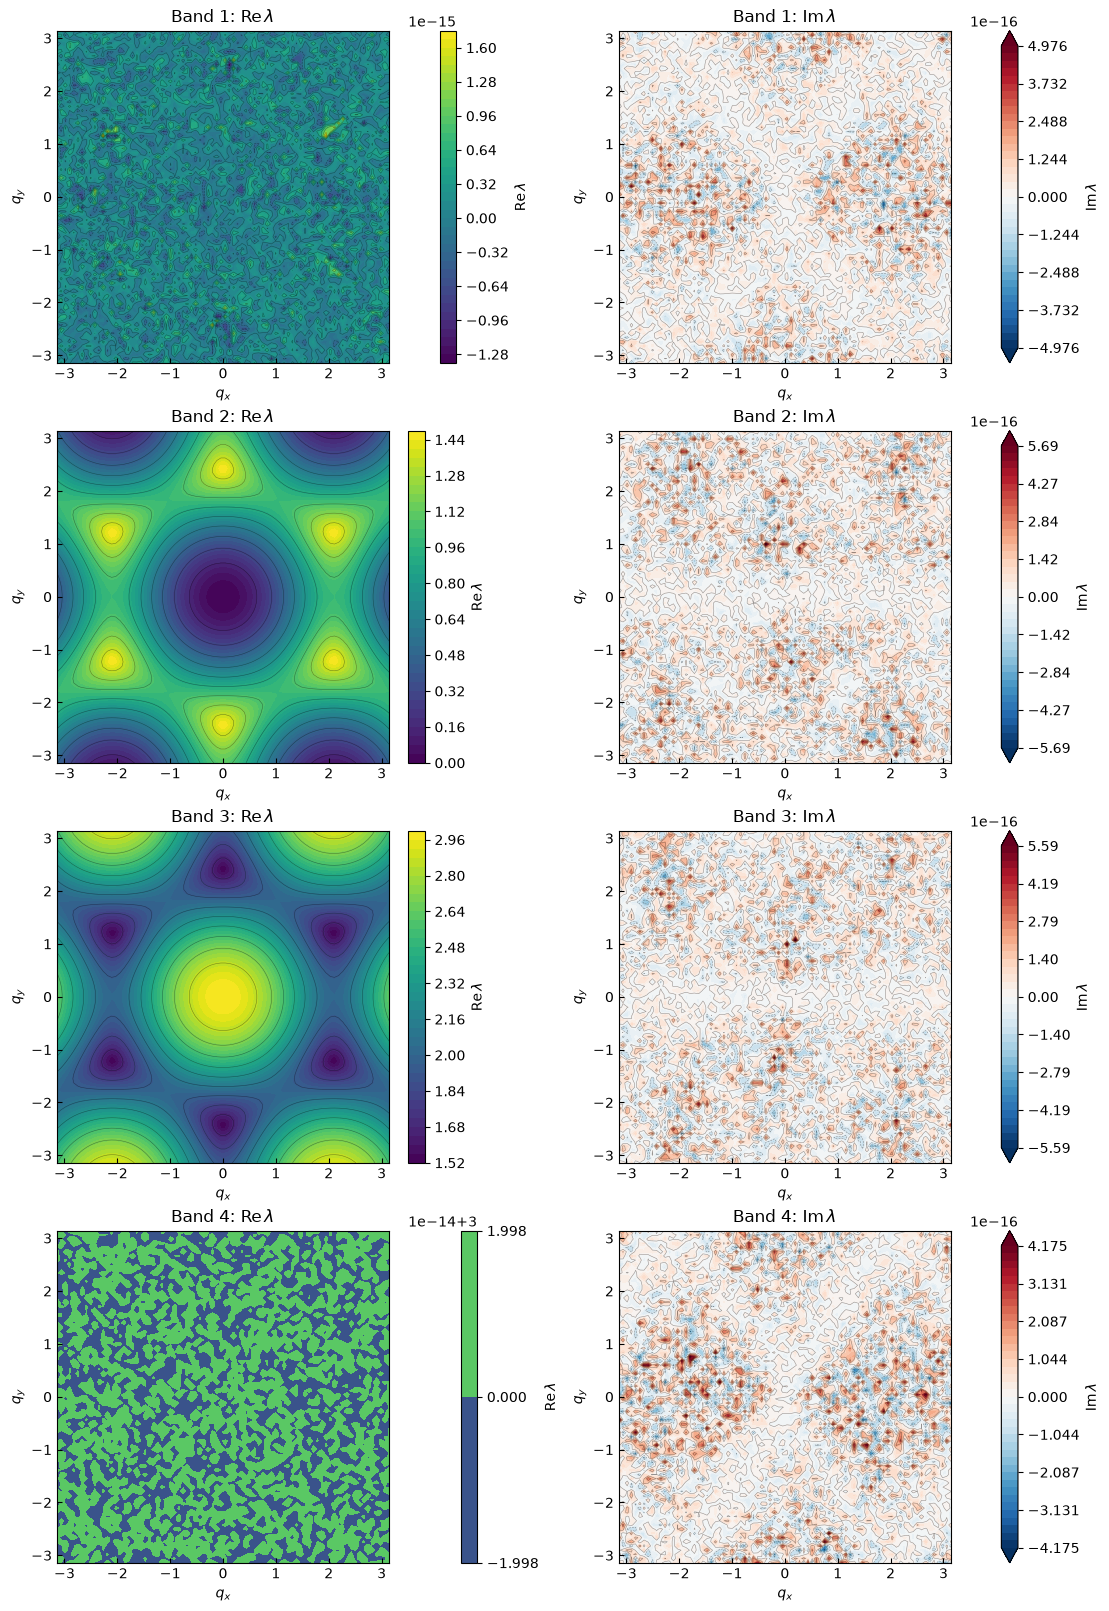

In [37]:
# Diagonlize, Add a BZ plot, and an eigenvalue plot
import numpy as np
import matplotlib.pyplot as plt

# Substitute numerical parameter values before lambdifying.
D_numeric = sp.lambdify(
    (qx, qy),
    dynamical_physical.subs({
        k: 1.0,
        kappa: 1.0
    }),
    modules="numpy",
)

# A few rectangles in Q space, so we can see the periodicity of the spectrum.
xlim=np.pi 
ylim=np.pi

qx_values = np.linspace(-xlim, xlim, 80)
qy_values = np.linspace(-ylim, ylim, 80)
QX, QY = np.meshgrid(qx_values, qy_values)

number_of_bands = dynamical_physical.shape[0]
eigenvalues = np.empty((*QX.shape, number_of_bands), dtype=complex)

for iy in range(len(qy_values)):
    for ix in range(len(qx_values)):
        matrix = np.asarray(
            D_numeric(qx_values[ix], qy_values[iy]),
            dtype=complex,
        )

        values = np.linalg.eigvals(matrix) # for each q, get the eignvalues \lambda(q)

        # Consistent ordering for plotting.
        order = np.lexsort((values.imag, values.real))
        eigenvalues[iy, ix] = values[order]

# First up, some 3D plots. Plot real and imaginary parts.
fig = plt.figure(figsize=(13, 5))

ax_real = fig.add_subplot(121, projection="3d")
ax_imag = fig.add_subplot(122, projection="3d")

for band in range(number_of_bands):
    ax_real.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].real,
        alpha=0.75,
    )

    ax_imag.plot_surface(
        QX,
        QY,
        eigenvalues[:, :, band].imag,
        alpha=0.75,
    )

ax_real.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Re}\,\lambda$",
    title="Real part of the spectrum",
)

ax_imag.set(
    xlabel=r"$q_x$",
    ylabel=r"$q_y$",
    zlabel=r"$\mathrm{Im}\,\lambda$",
    title="Imaginary part of the spectrum",
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    number_of_bands,
    2,
    figsize=(11, 4 * number_of_bands),
    constrained_layout=True,
    squeeze=False,
)

for band in range(number_of_bands):
    real_part = eigenvalues[:, :, band].real
    imag_part = eigenvalues[:, :, band].imag

    # Real part
    real_plot = axes[band, 0].contourf(
        QX,
        QY,
        real_part,
        levels=40,
        cmap="viridis",
    )

    axes[band, 0].contour(
        QX,
        QY,
        real_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        real_plot,
        ax=axes[band, 0],
        label=r"$\mathrm{Re}\,\lambda$",
    )

    # Use a symmetric colour scale for the imaginary part.
    imag_limit = np.max(np.abs(imag_part))

    if imag_limit > 0:
        imag_levels = np.linspace(-imag_limit, imag_limit, 41)
    else:
        imag_levels = 40

    imag_plot = axes[band, 1].contourf(
        QX,
        QY,
        imag_part,
        levels=imag_levels,
        cmap="RdBu_r",
        extend="both",
    )

    axes[band, 1].contour(
        QX,
        QY,
        imag_part,
        levels=10,
        colors="black",
        linewidths=0.4,
        alpha=0.4,
    )

    fig.colorbar(
        imag_plot,
        ax=axes[band, 1],
        label=r"$\mathrm{Im}\,\lambda$",
    )

    axes[band, 0].set_title(
        rf"Band {band + 1}: $\mathrm{{Re}}\,\lambda$"
    )
    axes[band, 1].set_title(
        rf"Band {band + 1}: $\mathrm{{Im}}\,\lambda$"
    )

    for ax in axes[band]:
        ax.set_xlabel(r"$q_x$")
        ax.set_ylabel(r"$q_y$")
        ax.set_aspect("equal")
        ax.tick_params(direction="in")

plt.show()



### Excercise 14 (5 mins) - What does it mean?

Interesting! Ok alot going on above. Lets discuss


- What do you notice about the dimensions of $D(q)$, in contrast to the triangular lattice?
- What do you notice about some of the bands above? Try adding a bit of torsional rigidity to the above code, and watch what happens to them bands. What could be the interpretation of these bands?

<details>
<summary><strong>Show answer</strong></summary>

- $D(q)$ is twice as big, because there are 2 balls per unit cell.

- There is a whole band of $0$ eigenvalues! This turns out to be related to the fact that the honeycomb lattice is *floppy* - it has a zero shear modulus.
</details>

# Part 3: The elastic moduli



The stiffness matrix $K^{ab}$ can be extracted from the dynamical matrix as in
Eq. C3 of [1]. We use a Voigt-like notation in which stresses and
unsymmetrized strains are decomposed in the basis

$$
\tau^0=\begin{pmatrix}1&0\\0&1\end{pmatrix},\quad
\tau^1=\begin{pmatrix}0&-1\\1&0\end{pmatrix},\quad
\tau^2=\begin{pmatrix}1&0\\0&-1\end{pmatrix},\quad
\tau^3=\begin{pmatrix}0&1\\1&0\end{pmatrix}.
$$

Thus $\sigma_{ij}=\sigma^a\tau^a_{ij}$ and
$\sigma^a=K^{ab}\varepsilon^b$. Here $\sigma^0$ represents dilation, while
$\sigma^2$ and $\sigma^3$ represent pure shears. In an isotropic lattice,
$K^{00}=B/2$ and $K^{22}=K^{33}=\mu/2$ in this convention.

**The crucial point:** passive lattices have the major symmetry
$K^{ab}=K^{ba}$ as a consequence of energy conservation. Active lattices can
violate this constraint.

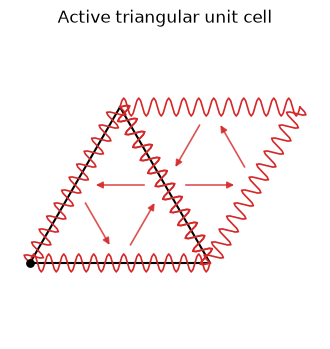

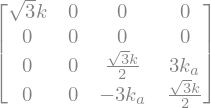

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
graphics.draw_unit_cell(Trigeom, ax=ax)
ax.set_title("Active triangular unit cell")
ax.axis("off")
plt.show()

stiffness_triangular = odd.stiffness_matrix(Trigeom)
display(stiffness_triangular)

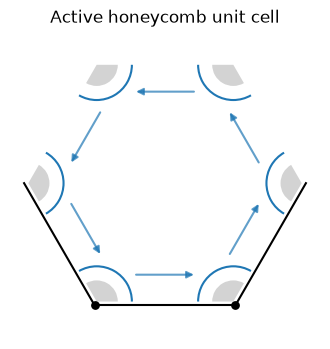

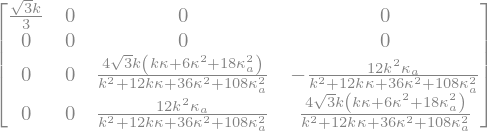

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))
graphics.draw_unit_cell(hgeom, ax=ax)
ax.set_title("Active honeycomb unit cell")
ax.axis("off")
plt.show()

stiffness_honeycomb = odd.stiffness_matrix(hgeom)
display(stiffness_honeycomb)

For both examples, the active shear block is antisymmetric:
$K^{23}=-K^{32}$. This purely antisymmetric off-diagonal component scales with
the microscopic activity and violates Maxwell–Betti reciprocity. It is the
**odd modulus** $K^o$. By coupling shear modes antisymmetrically, it can lead to
persistent cyclic motion and limit-cycle dynamics; see [3, 4].



